## 1. Install Library

In [1]:
!pip install kagglehub tensorflow matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Library

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 3. Download Dataset Otomatis

In [9]:
import kagglehub

path = kagglehub.dataset_download("farzadnekouei/trash-type-image-dataset")
print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")

Dataset path: C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1 -> 0 files
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset -> 0 files
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\cardboard -> 403 files
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\glass -> 501 files
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\metal -> 410 files
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\paper -> 594 files
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\plastic -> 482 files

## 4. Eksplorasi Dataset

In [10]:
data_dir = path
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)), "gambar")

TrashType_Image_Dataset : 6 gambar


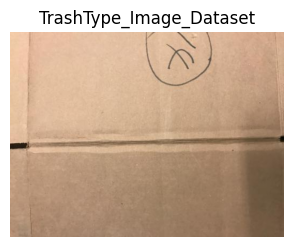

In [ ]:
classes = os.listdir(data_dir)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    cls_path = os.path.join(data_dir, cls)

    inner_folder = os.path.join(cls_path, os.listdir(cls_path)[0])

    image_files = [f for f in os.listdir(inner_folder)
                   if f.lower().endswith((".jpg",".jpeg",".png"))]

    img = plt.imread(os.path.join(inner_folder, image_files[0]))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

## 5. Split Data & Image Data Generator (Tahap Awal - Tanpa Augmentasi)

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

num_classes = train_gen.num_classes
print("Jumlah kelas:", num_classes)
print(train_gen.class_indices)

Found 2022 images belonging to 1 classes.
Found 505 images belonging to 1 classes.
Jumlah kelas: 1
{'TrashType_Image_Dataset': 0}


## 6. Membangun Model dengan Transfer Learning (MobileNetV2)

In [14]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Training Model (Baseline)

In [16]:
EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 339ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 343ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 344ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 362ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 355ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 367ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 475ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s

## 8. Evaluasi & Cek Overfitting

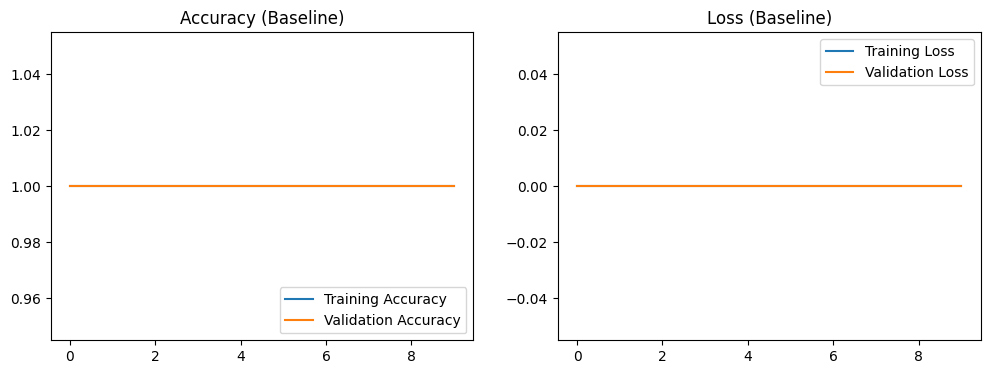

In [17]:
def plot_history(history, title=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title(f"Accuracy {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title(f"Loss {title}")
    plt.show()

plot_history(history, "(Baseline)")

In [18]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
gap = final_train_acc - final_val_acc

print(f"Training Accuracy   : {final_train_acc:.4f}")
print(f"Validation Accuracy : {final_val_acc:.4f}")
print(f"Gap (train - val)   : {gap:.4f}")

if gap > 0.1:
    print("\n>> Indikasi OVERFITTING terdeteksi (gap akurasi > 10%).")
else:
    print("\n>> Tidak ada indikasi overfitting yang signifikan.")

Training Accuracy   : 1.0000
Validation Accuracy : 1.0000
Gap (train - val)   : 0.0000

>> Tidak ada indikasi overfitting yang signifikan.


## 9. Handling Overfitting

### 9.1 Data Augmentation

In [19]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen_aug = train_datagen_aug.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen_aug = val_datagen_aug.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2022 images belonging to 1 classes.
Found 505 images belonging to 1 classes.


### 9.2 Model dengan Dropout + L2 Regularization

In [20]:
from tensorflow.keras import regularizers

base_model2 = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model2.trainable = False

model2 = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 9.3 Training dengan Early Stopping

In [21]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history2 = model2.fit(
    train_gen_aug,
    validation_data=val_gen_aug,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 698ms/step - accuracy: 1.0000 - loss: 0.2018 - val_accuracy: 1.0000 - val_loss: 0.1724
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 655ms/step - accuracy: 1.0000 - loss: 0.1491 - val_accuracy: 1.0000 - val_loss: 0.1267
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 719ms/step - accuracy: 1.0000 - loss: 0.1089 - val_accuracy: 1.0000 - val_loss: 0.0923
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 690ms/step - accuracy: 1.0000 - loss: 0.0791 - val_accuracy: 1.0000 - val_loss: 0.0666
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 811ms/step - accuracy: 1.0000 - loss: 0.0566 - val_accuracy: 1.0000 - val_loss: 0.0474
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 694ms/step - accuracy: 1.0000 - loss: 0.0402 - val_accuracy: 1.0000 - val_loss: 0.0334
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 661ms/step - accuracy: 1.0000 - loss: 0.0281 - val_accuracy: 1.0000 - val_loss: 0.0232
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 597ms/step - accuracy: 1.0000 - loss: 0.0194 - val_accu

## 10. Evaluasi Model Setelah Handling Overfitting

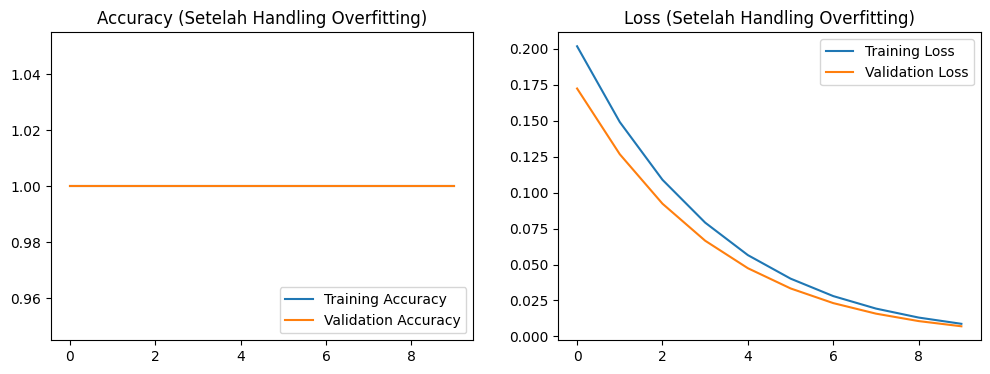

Training Accuracy   : 1.0000
Validation Accuracy : 1.0000
Gap (train - val)   : 0.0000

=== Perbandingan ===
Gap sebelum handling : 0.0000
Gap sesudah handling : 0.0000


In [22]:
plot_history(history2, "(Setelah Handling Overfitting)")

final_train_acc2 = history2.history["accuracy"][-1]
final_val_acc2 = history2.history["val_accuracy"][-1]
gap2 = final_train_acc2 - final_val_acc2

print(f"Training Accuracy   : {final_train_acc2:.4f}")
print(f"Validation Accuracy : {final_val_acc2:.4f}")
print(f"Gap (train - val)   : {gap2:.4f}")

print("\n=== Perbandingan ===")
print(f"Gap sebelum handling : {gap:.4f}")
print(f"Gap sesudah handling : {gap2:.4f}")

## 11. Fine-Tuning Base Model

In [24]:
base_model2.trainable = True

fine_tune_at = len(base_model2.layers) - 30
for layer in base_model2.layers[:fine_tune_at]:
    layer.trainable = False

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model2.fit(
    train_gen_aug,
    validation_data=val_gen_aug,
    epochs=10,
    callbacks=[early_stop]
)

plot_history(history_fine, "(Fine-Tuning)")

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 847ms/step - accuracy: 1.0000 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 2/10
42/64 ━━━━━━━━━━━━━━━━━━━━ 17s 778ms/step - accuracy: 1.0000 - loss: 0.0061

KeyboardInterrupt: 